# Lab 6 — Equalization: ZF, MMSE, Adaptive LMS, Blind CMA and DFE

**Companion to Chapter 6.** When the delay spread approaches the symbol period,
neighbouring symbols overlap (ISI). This lab compares the classic single-carrier
remedies and shows why OFDM (Chapter 7) took over for wideband links.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown
import commlib as cl

cl.style()
rng = np.random.default_rng(6)
qpsk = cl.get_constellation("qpsk")
qam16 = cl.get_constellation("16qam")

## 1. An ISI channel and its frequency response
$h = [1,\ a\,e^{j\theta},\ 0.2]$. As $a \to 1$ a deep spectral null appears.
A zero-forcing equalizer inverts the channel, amplifying noise at the null;
MMSE balances ISI against noise.

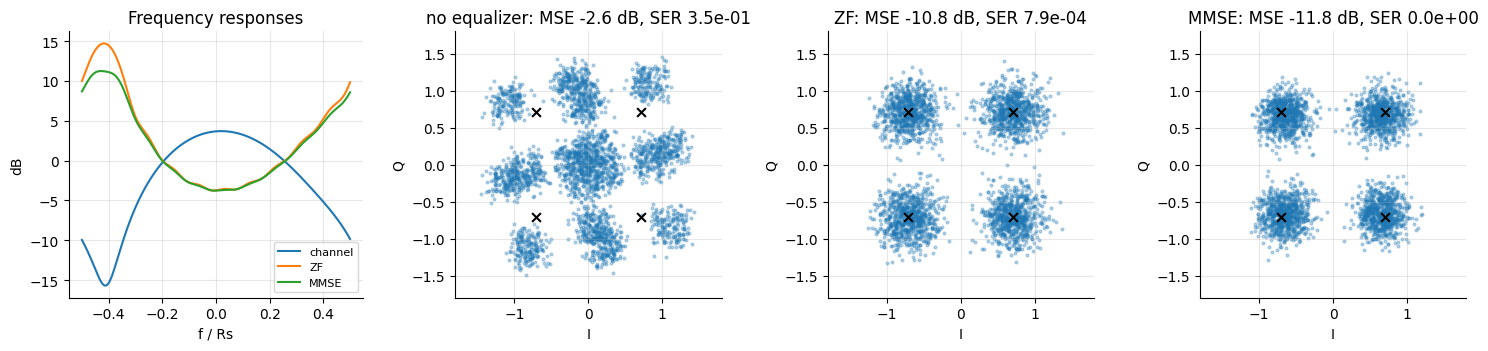

In [3]:
def channel(a=0.9, theta=0.3):
    return np.array([1, a * np.exp(1j * theta), 0.2]) / np.sqrt(1 + a ** 2 + 0.04)

def compare(a=0.9, esn0_db=18.0, L=21, mod="qpsk"):
    c = cl.get_constellation(mod)
    h = channel(a)
    bits = cl.random_bits(c.k * 8000, rng)
    s = c.modulate(bits)
    y = np.convolve(s, h)[:len(s)]
    y, n0 = cl.awgn_esn0(y, esn0_db, rng=rng, es=1.0)
    wz, dz = cl.zf_fir(h, L)
    wm, dm = cl.mmse_fir(h, L, n0)
    zz, zm = cl.apply_fir(y, wz, dz), cl.apply_fir(y, wm, dm)
    fig, ax = plt.subplots(1, 4, figsize=(15, 3.6))
    f = np.linspace(-0.5, 0.5, 512)
    H = np.fft.fftshift(np.fft.fft(h, 512)); WZ = np.fft.fftshift(np.fft.fft(wz, 512)); WM = np.fft.fftshift(np.fft.fft(wm, 512))
    ax[0].plot(f, 20 * np.log10(np.abs(H)), label="channel")
    ax[0].plot(f, 20 * np.log10(np.abs(WZ)), label="ZF"); ax[0].plot(f, 20 * np.log10(np.abs(WM)), label="MMSE")
    ax[0].set_xlabel("f / Rs"); ax[0].set_ylabel("dB"); ax[0].legend(fontsize=8); ax[0].set_title("Frequency responses")
    for axi, z, nm in [(ax[1], y, "no equalizer"), (ax[2], zz, "ZF"), (ax[3], zm, "MMSE")]:
        sl = slice(200, -200)
        ser = np.mean(c.decide(z[sl]) != s[sl]); mse = 10 * np.log10(np.mean(np.abs(z[sl] - s[sl]) ** 2))
        cl.plot_constellation(axi, z[sl][:3000], c.points, f"{nm}: MSE {mse:.1f} dB, SER {ser:.1e}", lim=1.8)
    plt.tight_layout(); plt.show()

interact(compare, a=FloatSlider(value=0.9, min=0, max=1.0, step=0.02, description="null depth a"),
         esn0_db=FloatSlider(value=18, min=5, max=35, step=1), L=IntSlider(value=21, min=3, max=61, step=2),
         mod=Dropdown(options=["qpsk", "16qam"], value="qpsk"));

## 2. Adaptive equalization with LMS
In practice the channel is unknown and changing. LMS updates
$\mathbf{w} \leftarrow \mathbf{w} + \mu\,\mathbf{u}\,e^*$ using a training sequence,
then switches to decision-directed mode. The step size trades convergence speed
against excess MSE (misadjustment $\approx \mu\,L\,P_u/2$).

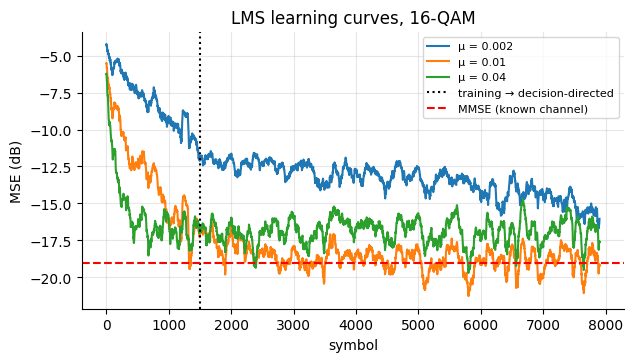

In [5]:
h = channel(0.8)
s = qam16.modulate(cl.random_bits(4 * 8000, rng))
y, n0 = cl.awgn_esn0(np.convolve(s, h)[:len(s)], 25, rng=rng, es=1.0)
fig, ax = plt.subplots(figsize=(7, 3.6))
for mu in [0.002, 0.01, 0.04]:
    _, err, _ = cl.lms_equalizer(y, s[:1500], L=15, mu=mu, constellation=qam16)
    ax.plot(10 * np.log10(np.convolve(err, np.ones(100) / 100, mode="valid")), label=f"μ = {mu}")
ax.axvline(1500, color="k", ls=":", label="training → decision-directed")
wm, dm = cl.mmse_fir(h, 15, n0); zm = cl.apply_fir(y, wm, dm)
ax.axhline(10 * np.log10(np.mean(np.abs(zm[200:-200] - s[200:-200]) ** 2)), color="r", ls="--", label="MMSE (known channel)")
ax.set_xlabel("symbol"); ax.set_ylabel("MSE (dB)"); ax.legend(fontsize=8); ax.set_title("LMS learning curves, 16-QAM")
plt.show()

## 3. Blind equalization: the constant modulus algorithm
CMA minimizes $E[(|z|^2 - R_2)^2]$ without any training or carrier lock, because
the cost is phase-invariant. It is the default blind equalizer in GNU Radio's PSK
receiver chain and in `gr02_psk_link.py`. It leaves a phase ambiguity, resolved
afterwards by the carrier loop and the preamble.

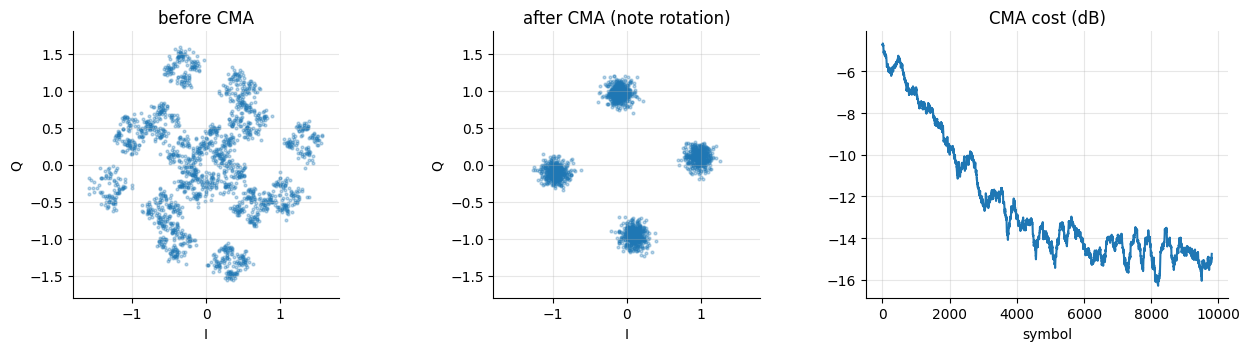

In [7]:
s = qpsk.modulate(cl.random_bits(2 * 10000, rng))
y, _ = cl.awgn_esn0(np.convolve(s, channel(0.7))[:len(s)] * np.exp(1j * 0.9), 22, rng=rng, es=1.0)
z, cost, w = cl.cma_equalizer(y, L=15, mu=3e-3)
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
cl.plot_constellation(ax[0], y[-2000:], title="before CMA", lim=1.8)
cl.plot_constellation(ax[1], z[-2000:], title="after CMA (note rotation)", lim=1.8)
ax[2].plot(10 * np.log10(np.convolve(cost, np.ones(200) / 200, mode="valid"))); ax[2].set_title("CMA cost (dB)")
ax[2].set_xlabel("symbol"); plt.tight_layout(); plt.show()

## 4. Decision-feedback equalization
A DFE cancels post-cursor ISI using past decisions, so it does not amplify noise
at spectral nulls the way a linear equalizer must. The risk is error propagation.

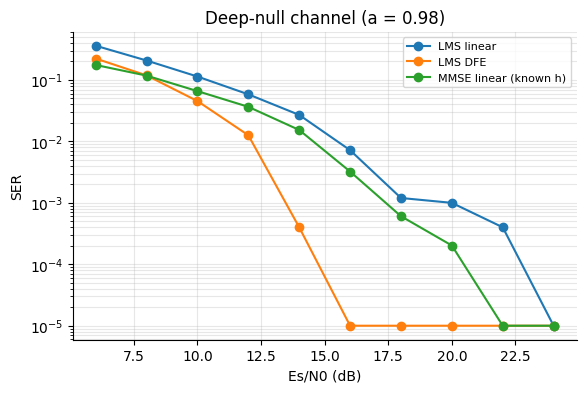

In [9]:
eb = np.arange(6, 25, 2)
h = channel(0.98)
fig, ax = plt.subplots(figsize=(6.5, 4))
res = {"LMS linear": [], "LMS DFE": [], "MMSE linear (known h)": []}
for e in eb:
    s = qpsk.modulate(cl.random_bits(2 * 6000, rng))
    y, n0 = cl.awgn_esn0(np.convolve(s, h)[:len(s)], e, rng=rng, es=1.0)
    out, _, _ = cl.lms_equalizer(y, s[:1000], L=21, mu=0.01, constellation=qpsk)
    res["LMS linear"].append(np.mean(qpsk.decide(out[1000:]) != s[1000:]))
    out, _, _ = cl.dfe_lms(y, s[:1000], qpsk, Lf=11, Lb=4, mu=0.01)
    res["LMS DFE"].append(np.mean(qpsk.decide(out[1000:]) != s[1000:]))
    wm, dm = cl.mmse_fir(h, 21, n0); zm = cl.apply_fir(y, wm, dm)
    res["MMSE linear (known h)"].append(np.mean(qpsk.decide(zm[1000:-50]) != s[1000:-50]))
for k, v in res.items():
    ax.semilogy(eb, np.maximum(v, 1e-5), "o-", label=k)
cl.ber_axes(ax, "Es/N0 (dB)"); ax.set_ylabel("SER"); ax.legend(fontsize=8)
ax.set_title("Deep-null channel (a = 0.98)"); plt.show()

## Exercises
1. **(Warm-up)** Show that the infinite-length ZF equalizer's output noise variance is
   $N_0 \int |H(f)|^{-2} df$ and explain why it diverges for a spectral null.
2. **(Core)** Sweep the decision delay of the MMSE FIR from 0 to L+2 and plot MSE. Why
   is the optimum near the middle for this channel?
3. **(Core)** Implement fractionally spaced (T/2) LMS and show it is insensitive to the
   sampling phase, unlike the T-spaced version.
4. **(Stretch)** Implement a 4-state MLSE (Viterbi) equalizer for BPSK over
   $h=[1, 0.9]$ and compare it with the DFE.